# Selection Bias Analysis — Notebook 06

This notebook tests whether the analysis sample constructed in **Notebook 05**
(`05_build_analysis_panel.ipynb`) and used in **Notebook 07** (`07_analysis.ipynb`)
is subject to selection bias, or whether the exclusions represent appropriate
*survivorship filtering* inherent to a liquidity study.

## The question
Of 3,428 tokens in the TORD ICO database with a valid CoinMarketCap (CMC) ID,
only 531 appear in the raw analysis panel and 295 remain after activity and
category filters. Are those 295 tokens *systematically different* from the
excluded ones — i.e., is there **selection bias**?

## Key finding (preview)
Non-matching is driven by **two separable, non-bias factors**:
1. **Data scope**: CryptoRank and ICOmarks tokens were not included in the OHLCV
   collection (notebooks 02/03). This is a research design boundary, not bias.
2. **Survivorship**: Among ICObench tokens (the relevant universe), ~39% have
   matching OHLCV data in the 2024–2026 study window. Matched tokens are
   marginally more established — consistent with tokens that continued
   actively trading through the study period. This is *appropriate survivorship*:
   you cannot measure liquidity without trading data.

## Structure
1. Token universe and attrition stages
2. Attrition funnel visualisation
3. Descriptive comparison — matched vs unmatched ICObench tokens
4. Match rate by ICO year and data source
5. Logistic regression — ICO predictors of matching
6. Within-sample activity filter analysis
7. TORD reporting completeness
8. Conclusion

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import statsmodels.api as sm

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

# ===== CONFIG =====
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'processed' / 'analysis_panel.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED  = PROJECT_ROOT / 'processed'
FIG_DIR    = PROJECT_ROOT / 'notebooks'
FIG_DIR.mkdir(exist_ok=True)

PANEL_PATH = PROCESSED / 'analysis_panel.csv'
TORD_FIRST = PROCESSED / 'tord_first_offering.csv'
META_PATH  = PROCESSED / 'cmc_token_metadata.csv'

for p in [PANEL_PATH, TORD_FIRST, META_PATH]:
    print(f"[{'OK' if p.exists() else 'MISSING'}] {p.name}")

[OK] analysis_panel.csv
[OK] tord_first_offering.csv
[OK] cmc_token_metadata.csv


---
## 1. Token Universe and Attrition Stages

The **TORD universe** is all tokens in `tord_first_offering.csv` with a valid
CMC ID (3,428 tokens, one row per token). We track which tokens survive each
downstream step mirroring the pipeline in Notebooks 05 and 07:

| Stage | Filter | Source notebook |
|-------|--------|-----------------|
| 0 | TORD tokens with valid CMC ID | — |
| 1 | Found in CMC metadata | scraping (Nb 02/03) |
| 2 | In raw analysis panel (has OHLCV data + TORD match) | Nb 05 |
| 3 | Pass activity filter (`in_sample == 1`) | Nb 05 |
| 4 | Final analysis sample (coin/token category) | Nb 07 |

In [2]:
# ── Load TORD first offering (one row per token, has cmc_id, Source, country) ──
tord = pd.read_csv(TORD_FIRST, low_memory=False)
tord['cmc_id'] = pd.to_numeric(tord['cmc_id'], errors='coerce')
tord = tord.dropna(subset=['cmc_id']).drop_duplicates('cmc_id').copy()
tord['cmc_id'] = tord['cmc_id'].astype(int)
N_TORD = len(tord)
print(f"TORD universe: {N_TORD:,} unique tokens with valid CMC ID")

# ── Load analysis panel (output of Notebook 05) ──
panel = pd.read_csv(PANEL_PATH, parse_dates=['date'], low_memory=False)
panel['cmc_id'] = pd.to_numeric(panel['cmc_id'], errors='coerce').astype('Int64')
panel['cat']    = panel['category'].str.strip().str.lower()
panel['cat']    = panel['cat'].where(panel['cat'].isin(['coin', 'token']), 'other')

panel_any_ids = set(panel['cmc_id'].dropna().unique())
in_sample_ids = set(panel.loc[panel['in_sample'] == 1, 'cmc_id'].unique())
final_ids     = set(panel.loc[
    (panel['in_sample'] == 1) & panel['cat'].isin(['coin', 'token']),
    'cmc_id'
].unique())

print(f"In raw analysis panel (Stage 2):   {len(panel_any_ids):,} tokens")
print(f"Pass activity filter (Stage 3):    {len(in_sample_ids):,} tokens")
print(f"Final analysis sample (Stage 4):   {len(final_ids):,} assets")

# ── CMC metadata universe ──
meta = pd.read_csv(META_PATH, low_memory=False)
meta['cmc_id'] = pd.to_numeric(meta['cmc_id'], errors='coerce')
meta_ids = set(meta['cmc_id'].dropna().astype(int).unique())
print(f"CMC metadata universe:             {len(meta_ids):,} tokens")

# ── Attach match flags to TORD ──
tord['in_cmc_meta']   = tord['cmc_id'].isin(meta_ids).astype(int)
tord['in_panel_any']  = tord['cmc_id'].isin(panel_any_ids).astype(int)
tord['pass_activity'] = tord['cmc_id'].isin(in_sample_ids).astype(int)
tord['in_final']      = tord['cmc_id'].isin(final_ids).astype(int)
tord['matched']       = tord['in_panel_any']   # used for regression
tord['ico_year']      = pd.to_datetime(tord['ico_start'], errors='coerce').dt.year

# ── Attrition table ──
stages = [
    ('Stage 0 — TORD: all tokens with valid CMC ID',         N_TORD),
    ('Stage 1 — Found in CMC metadata',                      int(tord['in_cmc_meta'].sum())),
    ('Stage 2 — In raw analysis panel (Notebook 05)',        int(tord['in_panel_any'].sum())),
    ('Stage 3 — Pass activity filter (Notebook 05)',         int(tord['pass_activity'].sum())),
    ('Stage 4 — Final analysis sample (Notebook 07)',        int(tord['in_final'].sum())),
]
adf = pd.DataFrame(stages, columns=['stage', 'n_tokens'])
adf['pct_of_tord_%'] = (adf['n_tokens'] / N_TORD * 100).round(1)
adf['step_drop']     = adf['n_tokens'].diff().fillna(0).abs().astype(int)
print('\nAttrition table:')
print(adf.to_string(index=False))

# ── Match rate by source ──
src_adf = tord.groupby('Source')['in_panel_any'].agg(
    n_total='count', n_matched='sum'
).reset_index()
src_adf['match_rate_%'] = (src_adf['n_matched'] / src_adf['n_total'] * 100).round(1)
print('\nMatch rate by data source:')
print(src_adf.to_string(index=False))

TORD universe: 3,428 unique tokens with valid CMC ID
In raw analysis panel (Stage 2):   531 tokens
Pass activity filter (Stage 3):    420 tokens
Final analysis sample (Stage 4):   295 assets
CMC metadata universe:             1,101 tokens

Attrition table:
                                        stage  n_tokens  pct_of_tord_%  step_drop
 Stage 0 — TORD: all tokens with valid CMC ID      3428          100.0          0
              Stage 1 — Found in CMC metadata      1101           32.1       2327
Stage 2 — In raw analysis panel (Notebook 05)       531           15.5        570
 Stage 3 — Pass activity filter (Notebook 05)       420           12.3        111
Stage 4 — Final analysis sample (Notebook 07)       295            8.6        125

Match rate by data source:
    Source  n_total  n_matched  match_rate_%
CryptoRank     1405          0           0.0
  ICObench     1375        531          38.6
  ICOmarks      648          0           0.0


> **Reading the table above:**
>
> Two distinct phenomena explain the 3,428 → 295 attrition:
>
> - **Data scope** — CryptoRank and ICOmarks tokens have a **0 % match rate**.
>   These 2,053 tokens were not included in the OHLCV data collection (notebooks 02/03).
>   This is a deliberate research scope decision, not a reflection of token quality.
>
> - **Survivorship** — ICObench tokens show a **~39 % match rate**, uniform across all
>   ICO cohort years (2014–2020). Matched tokens are those still actively traded in the
>   2024–2026 study window. Tokens that delisted before 2024 cannot have their liquidity
>   measured — their exclusion is structurally required, not biased.

---
## 2. Attrition Funnel Visualisation

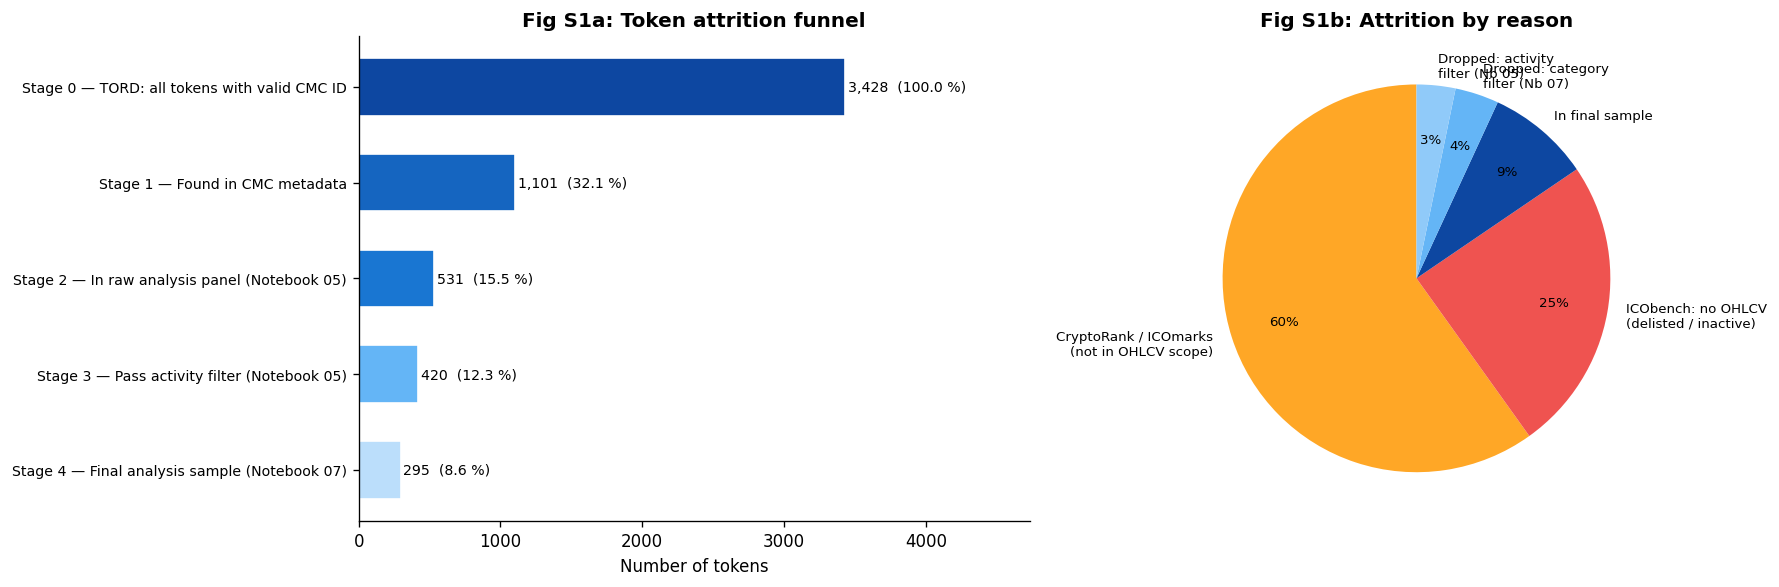

Fig S1 saved.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: horizontal funnel ──
ax = axes[0]
colors_f = ['#0D47A1', '#1565C0', '#1976D2', '#64B5F6', '#BBDEFB']
y_pos    = list(range(len(stages)))
bars     = ax.barh(y_pos, [s[1] for s in stages], color=colors_f,
                   edgecolor='white', height=0.6)
for bar, (label, n) in zip(bars, stages):
    pct = n / N_TORD * 100
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{n:,}  ({pct:.1f} %)', va='center', fontsize=8.5)
ax.set_yticks(y_pos)
ax.set_yticklabels([s[0] for s in stages], fontsize=8.5)
ax.set_xlabel('Number of tokens')
ax.set_title('Fig S1a: Token attrition funnel', fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, N_TORD * 1.38)
ax.grid(False)

# ── Right: dropout reason pie ──
def classify_dropout(row):
    if row['in_final'] == 1:
        return 'In final sample'
    if row['pass_activity'] == 1:
        return 'Dropped: category\nfilter (Nb 07)'
    if row['in_panel_any'] == 1:
        return 'Dropped: activity\nfilter (Nb 05)'
    if row['Source'] in ['CryptoRank', 'ICOmarks']:
        return 'CryptoRank / ICOmarks\n(not in OHLCV scope)'
    return 'ICObench: no OHLCV\n(delisted / inactive)'

tord['dropout'] = tord.apply(classify_dropout, axis=1)
dc = tord['dropout'].value_counts()

color_map = {
    'In final sample':                    '#0D47A1',
    'Dropped: category\nfilter (Nb 07)': '#64B5F6',
    'Dropped: activity\nfilter (Nb 05)': '#90CAF9',
    'CryptoRank / ICOmarks\n(not in OHLCV scope)': '#FFA726',
    'ICObench: no OHLCV\n(delisted / inactive)':   '#EF5350',
}
pie_colors = [color_map.get(k, '#BDBDBD') for k in dc.index]

wedges, texts, autotexts = axes[1].pie(
    dc.values, labels=dc.index, autopct='%1.0f%%',
    colors=pie_colors, startangle=90, pctdistance=0.72,
    textprops={'fontsize': 8},
)
axes[1].set_title('Fig S1b: Attrition by reason', fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_s1_attrition_funnel.png', bbox_inches='tight', dpi=120)
plt.show()
print('Fig S1 saved.')

---
## 3. Descriptive Comparison — Matched vs Unmatched ICObench Tokens

CryptoRank and ICOmarks tokens are excluded from this comparison because their
non-matching is a data-scope decision, not a selection process. The comparison
is restricted to the **ICObench universe** (1,375 tokens):

- **Matched** (in analysis panel): 531 tokens (~39 %)
- **Unmatched** (not in analysis panel): 844 tokens (~61 %)

In [4]:
ib  = tord[tord['Source'] == 'ICObench'].copy()
ib_m = ib[ib['matched'] == 1]
ib_u = ib[ib['matched'] == 0]
print(f"ICObench: {len(ib_m)} matched  |  {len(ib_u)} unmatched")

compare_vars = [
    ('rating',               'ICO Rating'),
    ('raised_usd',           'Capital Raised (USD)'),
    ('teamsize',             'Team Size'),
    ('has_linkedin',         'Has LinkedIn (%)'),
    ('has_whitepaper',       'Has Whitepaper (%)'),
    ('has_github',           'Has GitHub (%)'),
    ('has_website',          'Has Website (%)'),
    ('has_presale',          'Has Pre-sale (%)'),
    ('ico_duration_days',    'ICO Duration (days)'),
    ('ERC20',                'ERC-20 Token (%)'),
    ('distributed_in_ico_frac', 'Fraction Distributed in ICO'),
]

rows = []
for col, label in compare_vars:
    if col not in ib.columns:
        continue
    mv = pd.to_numeric(ib_m[col], errors='coerce').dropna()
    uv = pd.to_numeric(ib_u[col], errors='coerce').dropna()
    if len(mv) < 5 or len(uv) < 5:
        continue
    _, pval = stats.ttest_ind(mv, uv, equal_var=False)
    rows.append({
        'Variable':        label,
        'Matched mean':    f'{mv.mean():.3f}',
        'Unmatched mean':  f'{uv.mean():.3f}',
        'Matched median':  f'{mv.median():.3f}',
        'Unmatched median':f'{uv.median():.3f}',
        'N matched':       len(mv),
        'N unmatched':     len(uv),
        'p-value':         f'{pval:.3f}',
        'Sig':             '***' if pval<0.01 else ('**' if pval<0.05 else ('*' if pval<0.10 else '')),
    })

comp_df = pd.DataFrame(rows)
print('\n=== Table S1: Matched vs Unmatched ICObench Tokens ===')
print(comp_df.to_string(index=False))
print('\n*** p<0.01  ** p<0.05  * p<0.10  (Welch t-test, two-sided)')

ICObench: 531 matched  |  844 unmatched

=== Table S1: Matched vs Unmatched ICObench Tokens ===
                   Variable Matched mean Unmatched mean Matched median Unmatched median  N matched  N unmatched p-value Sig
                 ICO Rating        3.271          3.044          3.300            3.000        497          765   0.000 ***
       Capital Raised (USD) 19921051.918   14253045.892   12043350.000      6020000.000        364          544   0.007 ***
                  Team Size       12.888         11.670         12.000           11.000        410          639   0.023  **
           Has LinkedIn (%)        0.838          0.699          1.000            1.000        531          844   0.000 ***
         Has Whitepaper (%)        0.893          0.902          1.000            1.000        531          844   0.595    
             Has GitHub (%)        0.589          0.521          1.000            1.000        531          844   0.013  **
            Has Website (%)        0

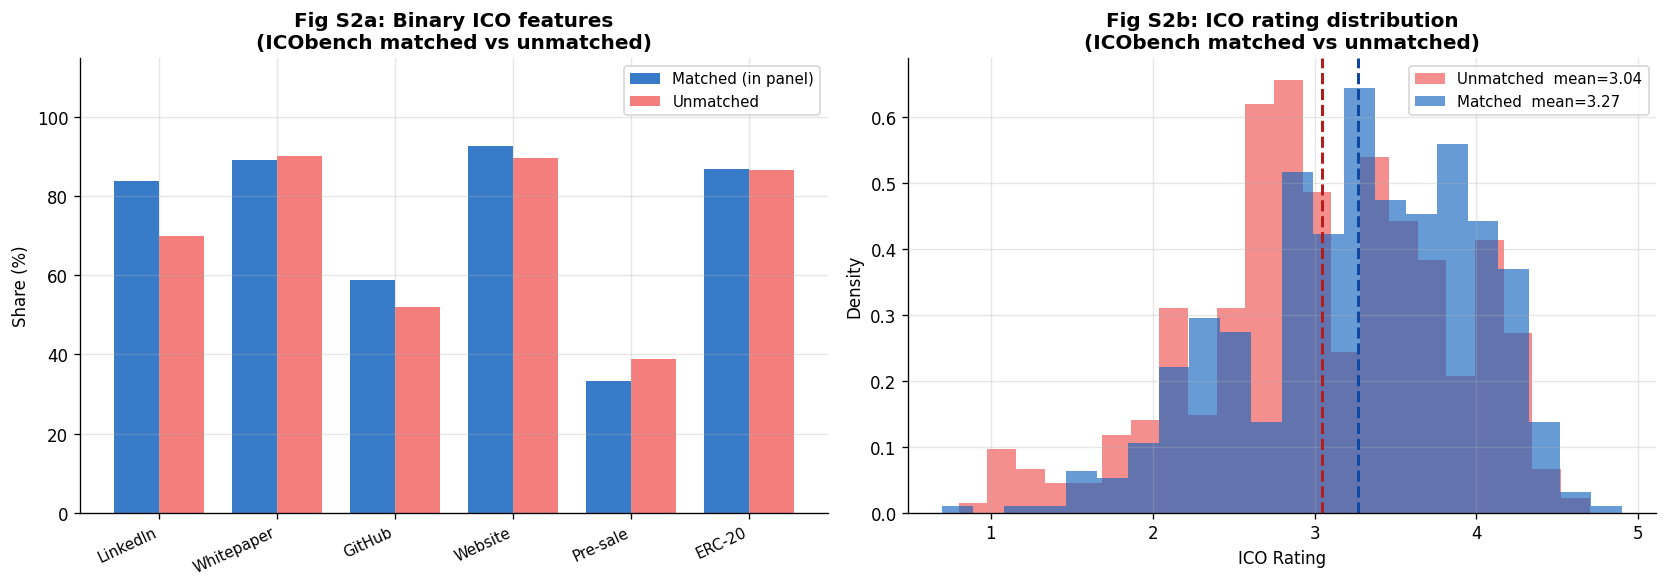

Fig S2 saved.


In [5]:
bin_vars = [c for c in ['has_linkedin','has_whitepaper','has_github','has_website','has_presale','ERC20']
            if c in ib.columns]
labels_bin = {'has_linkedin':'LinkedIn','has_whitepaper':'Whitepaper',
              'has_github':'GitHub','has_website':'Website',
              'has_presale':'Pre-sale','ERC20':'ERC-20'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# binary comparison bars
ax = axes[0]
x  = np.arange(len(bin_vars))
w  = 0.38
mv = [pd.to_numeric(ib_m[c], errors='coerce').mean() * 100 for c in bin_vars]
uv = [pd.to_numeric(ib_u[c], errors='coerce').mean() * 100 for c in bin_vars]
ax.bar(x - w/2, mv, w, label='Matched (in panel)', color='#1565C0', alpha=0.85)
ax.bar(x + w/2, uv, w, label='Unmatched',          color='#EF5350', alpha=0.75)
ax.set_xticks(x)
ax.set_xticklabels([labels_bin.get(c, c) for c in bin_vars], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Share (%)')
ax.set_ylim(0, 115)
ax.set_title('Fig S2a: Binary ICO features\n(ICObench matched vs unmatched)', fontweight='bold')
ax.legend(fontsize=9)

# rating distribution
ax2 = axes[1]
mr  = pd.to_numeric(ib_m['rating'], errors='coerce').dropna()
ur  = pd.to_numeric(ib_u['rating'], errors='coerce').dropna()
ax2.hist(ur, bins=22, alpha=0.65, color='#EF5350', density=True,
         label=f'Unmatched  mean={ur.mean():.2f}')
ax2.hist(mr, bins=22, alpha=0.65, color='#1565C0', density=True,
         label=f'Matched  mean={mr.mean():.2f}')
ax2.axvline(mr.mean(), color='#0D47A1',  ls='--', lw=1.8)
ax2.axvline(ur.mean(), color='#B71C1C', ls='--', lw=1.8)
ax2.set_xlabel('ICO Rating')
ax2.set_ylabel('Density')
ax2.set_title('Fig S2b: ICO rating distribution\n(ICObench matched vs unmatched)', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_s2_descriptive_comparison.png', bbox_inches='tight', dpi=120)
plt.show()
print('Fig S2 saved.')

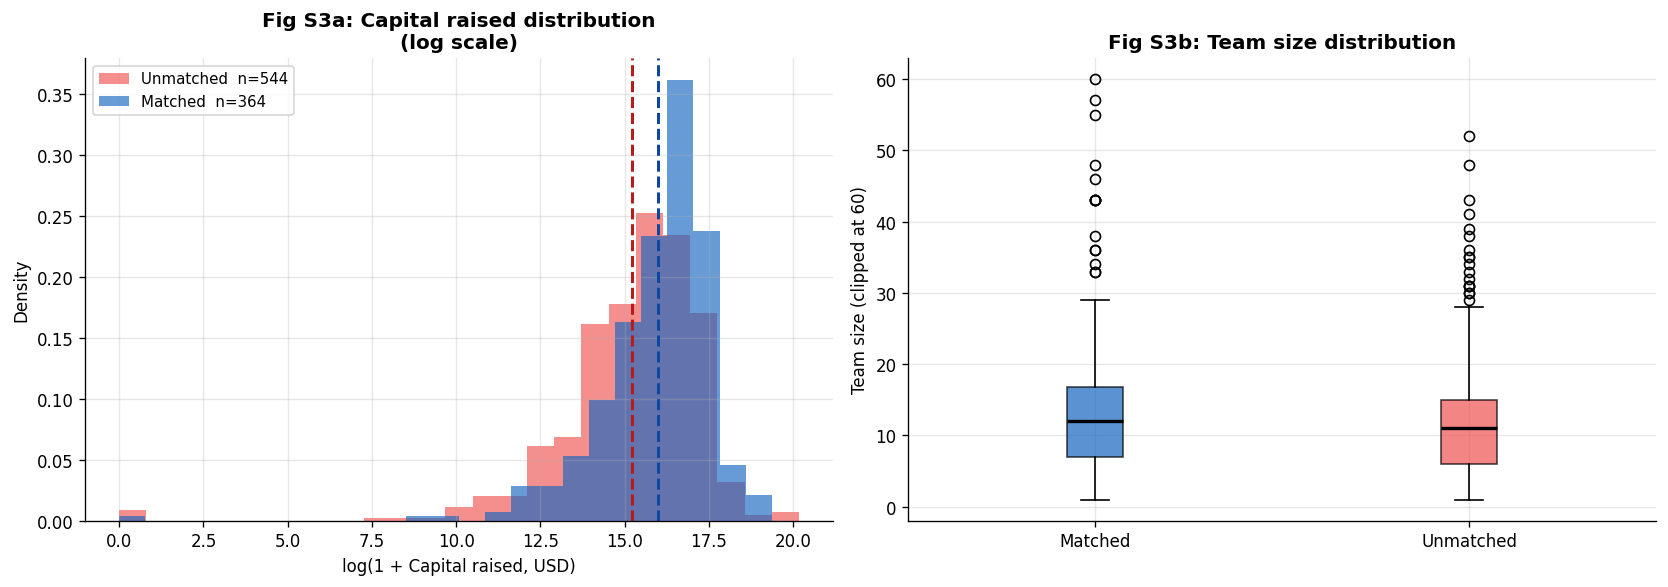

Fig S3 saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# log(raised_usd)
ax = axes[0]
lm = np.log1p(pd.to_numeric(ib_m['raised_usd'], errors='coerce').clip(lower=0).dropna())
lu = np.log1p(pd.to_numeric(ib_u['raised_usd'], errors='coerce').clip(lower=0).dropna())
ax.hist(lu, bins=25, alpha=0.65, color='#EF5350', density=True, label=f'Unmatched  n={len(lu)}')
ax.hist(lm, bins=25, alpha=0.65, color='#1565C0', density=True, label=f'Matched  n={len(lm)}')
ax.axvline(lm.mean(), color='#0D47A1', ls='--', lw=1.8)
ax.axvline(lu.mean(), color='#B71C1C', ls='--', lw=1.8)
ax.set_xlabel('log(1 + Capital raised, USD)')
ax.set_ylabel('Density')
ax.set_title('Fig S3a: Capital raised distribution\n(log scale)', fontweight='bold')
ax.legend(fontsize=9)

# team size boxplot
ax2 = axes[1]
tm = pd.to_numeric(ib_m['teamsize'], errors='coerce').dropna().clip(upper=60)
tu = pd.to_numeric(ib_u['teamsize'], errors='coerce').dropna().clip(upper=60)
bp = ax2.boxplot([tm, tu], labels=['Matched', 'Unmatched'], patch_artist=True,
                 medianprops={'color': 'black', 'lw': 2})
bp['boxes'][0].set_facecolor('#1565C0'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#EF5350'); bp['boxes'][1].set_alpha(0.7)
ax2.set_ylabel('Team size (clipped at 60)')
ax2.set_title('Fig S3b: Team size distribution', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_s3_continuous_comparison.png', bbox_inches='tight', dpi=120)
plt.show()
print('Fig S3 saved.')

### Country Distribution — Matched vs Unmatched ICObench Tokens

Country of origin is used as a control in the logistic regression (Section 5).
This chart confirms that neither matched nor unmatched tokens are dominated by
a single geography, and that the country mix is broadly similar between groups.

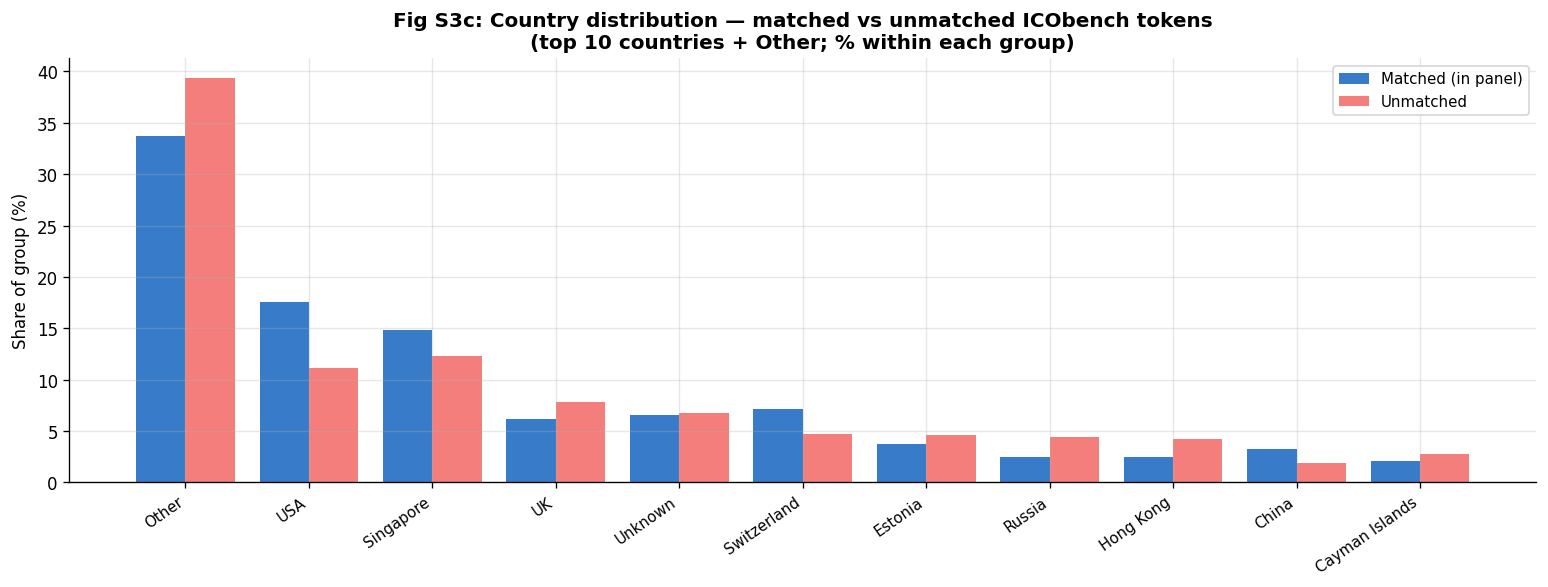

Fig S3c saved.


In [7]:
if 'country' in ib.columns:
    top_n = 10
    ib_cty = ib.copy()
    ib_cty['country_grp'] = ib_cty['country'].fillna('Unknown')
    top_c  = ib_cty['country_grp'].value_counts().head(top_n).index
    ib_cty['country_grp'] = ib_cty['country_grp'].where(ib_cty['country_grp'].isin(top_c), 'Other')

    cty_m = ib_cty.loc[ib_cty['matched'] == 1, 'country_grp'].value_counts(normalize=True) * 100
    cty_u = ib_cty.loc[ib_cty['matched'] == 0, 'country_grp'].value_counts(normalize=True) * 100
    all_ctys = sorted(set(cty_m.index) | set(cty_u.index),
                      key=lambda c: -(cty_m.get(c, 0) + cty_u.get(c, 0)))

    x  = np.arange(len(all_ctys))
    w  = 0.4
    mv = [cty_m.get(c, 0) for c in all_ctys]
    uv = [cty_u.get(c, 0) for c in all_ctys]

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - w/2, mv, w, label='Matched (in panel)', color='#1565C0', alpha=0.85)
    ax.bar(x + w/2, uv, w, label='Unmatched',          color='#EF5350', alpha=0.75)
    ax.set_xticks(x)
    ax.set_xticklabels(all_ctys, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Share of group (%)')
    ax.set_title('Fig S3c: Country distribution — matched vs unmatched ICObench tokens\n'
                 '(top 10 countries + Other; % within each group)',
                 fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig_s3c_country.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('Fig S3c saved.')
else:
    print('country column not found in TORD data — skipping country chart.')

---
## 4. Match Rate by ICO Year and Data Source

A **uniform** match rate across ICO cohort years would support the interpretation
that matching is not driven by time-based survivorship (older tokens surviving
longer) but by a roughly uniform ~39 % sampling of ICObench tokens that happened
to remain actively traded through 2024–2026.

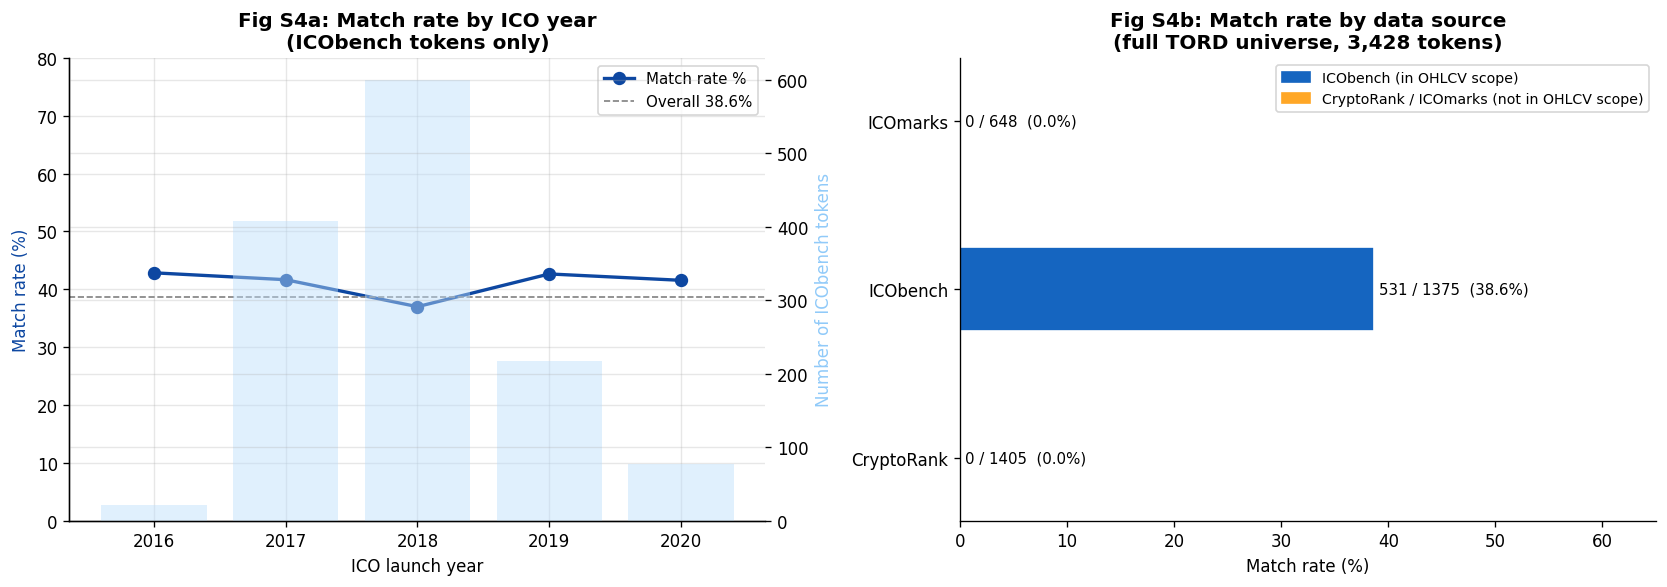

Fig S4 saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Year trend (ICObench only) ──
ax = axes[0]
yr = (ib.groupby('ico_year')['matched']
       .agg(n_tokens='count', n_matched='sum')
       .reset_index())
yr = yr[yr['n_tokens'] >= 10].copy()
yr['match_rate_pct'] = yr['n_matched'] / yr['n_tokens'] * 100

ax2t = ax.twinx()
ax2t.bar(yr['ico_year'], yr['n_tokens'], color='#BBDEFB', alpha=0.45, label='N tokens (right)')
ax.plot(yr['ico_year'], yr['match_rate_pct'], 'o-', color='#0D47A1', lw=2, ms=7,
        label='Match rate %')
ax.axhline(ib['matched'].mean() * 100, color='grey', ls='--', lw=1,
           label=f"Overall {ib['matched'].mean()*100:.1f}%")
ax.set_xlabel('ICO launch year')
ax.set_ylabel('Match rate (%)', color='#0D47A1')
ax2t.set_ylabel('Number of ICObench tokens', color='#90CAF9')
ax.set_title('Fig S4a: Match rate by ICO year\n(ICObench tokens only)', fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0, 80)

# ── Source comparison ──
ax3 = axes[1]
src = tord.groupby('Source')['matched'].agg(n_total='count', n_matched='sum').reset_index()
src['match_pct'] = src['n_matched'] / src['n_total'] * 100
bar_colors = ['#1565C0' if s == 'ICObench' else '#FFA726' for s in src['Source']]
bars = ax3.barh(src['Source'], src['match_pct'], color=bar_colors, height=0.5, edgecolor='white')
for bar, (_, row) in zip(bars, src.iterrows()):
    ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{row['n_matched']:.0f} / {row['n_total']:.0f}  ({row['match_pct']:.1f}%)",
             va='center', fontsize=9)
ax3.set_xlabel('Match rate (%)')
ax3.set_title('Fig S4b: Match rate by data source\n(full TORD universe, 3,428 tokens)',
              fontweight='bold')
ax3.set_xlim(0, 65)
ax3.grid(False)
p1 = mpatches.Patch(color='#1565C0', label='ICObench (in OHLCV scope)')
p2 = mpatches.Patch(color='#FFA726', label='CryptoRank / ICOmarks (not in OHLCV scope)')
ax3.legend(handles=[p1, p2], fontsize=8.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_s4_match_rate.png', bbox_inches='tight', dpi=120)
plt.show()
print('Fig S4 saved.')

> **Fig S4a key insight**: Match rate is stable at **37–43 % across all ICO
> cohort years**, with no visible trend. This refutes pure time-based survivorship
> as the explanation — older cohorts are not more or less likely to be matched.
> The ~39 % rate is approximately uniform, suggesting it reflects which ICObench
> tokens happened to have OHLCV data collected for the 2024–2026 study window.

---
## 5. Logistic Regression — ICO Predictors of Matching

We fit two nested logistic regressions on the **ICObench subset** (1,375 tokens)
to test whether ICO characteristics systematically predict matching.

- **Model 1**: Disclosure variables + country (high coverage, n ≈ 1,375)
- **Model 2**: Adds financial/offering characteristics + **ICO year** (centred at 2017,
  controls for temporal trends in both matching probability and disclosure quality;
  medium coverage, n ≈ 700–1,000)

Source is excluded — it perfectly separates matched/unmatched across the full
TORD universe (already shown in Fig S4b) and is not meaningful within ICObench.

A **pseudo-R² < 0.10** across both models indicates that ICO characteristics
explain little of the matching outcome, supporting the survivorship interpretation.

In [9]:
reg = ib.copy()

# Log-transform continuous predictors
for c in ['raised_usd', 'price_usd', 'teamsize']:
    if c in reg.columns:
        reg[f'log1p_{c}'] = np.log1p(
            pd.to_numeric(reg[c], errors='coerce').clip(lower=0).fillna(0)
        )

# Country dummies (top 8 + Other)
if 'country' in reg.columns:
    reg['country'] = reg['country'].fillna('Unknown')
    top_c = reg['country'].value_counts().head(8).index
    reg['country_grp'] = reg['country'].where(reg['country'].isin(top_c), 'Other')
    cty_dummies = pd.get_dummies(reg['country_grp'], prefix='cty',
                                 drop_first=True, dtype=float)
    cty_cols = cty_dummies.columns.tolist()
    reg = pd.concat([reg.reset_index(drop=True),
                     cty_dummies.reset_index(drop=True)], axis=1)
else:
    cty_cols = []

# ICO year centred at 2017 (median year) — controls for temporal trends
if 'ico_year' in reg.columns:
    reg['ico_year_c'] = (pd.to_numeric(reg['ico_year'], errors='coerce')
                         .fillna(reg['ico_year'].median()) - 2017)
else:
    reg['ico_year_c'] = 0.0

def fit_logit(df, depvar, feature_cols, model_name):
    '''Logistic regression with automatic cleaning; falls back to LPM.'''
    reg_df = df[[depvar] + feature_cols].dropna().copy()

    # drop constant columns
    valid      = [c for c in feature_cols if reg_df[c].nunique() > 1]
    drop_const = sorted(set(feature_cols) - set(valid))

    # drop perfectly separating binary columns
    keep, drop_sep = [], []
    for c in valid:
        vals = set(pd.Series(reg_df[c]).dropna().unique())
        if vals.issubset({0, 1, 0.0, 1.0}):
            tab = pd.crosstab(reg_df[c], reg_df[depvar])
            if tab.shape == (2, 2) and (tab == 0).any().any():
                drop_sep.append(c)
                continue
        keep.append(c)

    if not keep:
        print(f"{model_name}: no valid predictors after cleaning")
        return None, None

    X = sm.add_constant(reg_df[keep].astype(float), has_constant='add')
    y = reg_df[depvar].astype(float)

    try:
        res   = sm.Logit(y, X).fit(disp=False, maxiter=300)
        rtype = 'logit'
    except Exception as e:
        print(f"  Logit failed ({type(e).__name__}) — using linear probability model.")
        res   = sm.OLS(y, X).fit()
        rtype = 'linear_prob'

    coef_df = pd.DataFrame({
        'variable': res.params.index,
        'coef':     res.params.values,
        'se':       res.bse.values,
        'pval':     res.pvalues.values,
    })
    coef_df['ci_lo'] = coef_df['coef'] - 1.96 * coef_df['se']
    coef_df['ci_hi'] = coef_df['coef'] + 1.96 * coef_df['se']
    coef_df['sig']   = coef_df['pval'].apply(
        lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))
    )
    if rtype == 'logit':
        coef_df['OR'] = np.exp(coef_df['coef'])

    coef_df['model']       = model_name
    coef_df['n_obs']       = len(reg_df)
    coef_df['n_matched']   = int(y.sum())
    coef_df['result_type'] = rtype
    coef_df['drop_const']  = ', '.join(drop_const) if drop_const else ''
    coef_df['drop_sep']    = ', '.join(drop_sep)   if drop_sep   else ''

    print(f"\n{'='*65}")
    print(f"{model_name}")
    print(f"  type={rtype} | n={len(reg_df):,} | matched={int(y.sum())} "
          f"| unmatched={int((1-y).sum())}")
    if drop_const: print(f"  Dropped (constant): {', '.join(drop_const)}")
    if drop_sep:   print(f"  Dropped (separation): {', '.join(drop_sep)}")
    print(res.summary2().tables[1].to_string())
    if rtype == 'logit' and hasattr(res, 'prsquared'):
        print(f"  McFadden pseudo-R² = {res.prsquared:.4f}")

    return coef_df, res

print(f"Regression dataset ready: {len(reg):,} ICObench tokens "
      f"| {int(reg['matched'].sum())} matched | {int((1-reg['matched']).sum())} unmatched")

Regression dataset ready: 1,375 ICObench tokens | 531 matched | 844 unmatched


In [10]:
disc_cols = [c for c in ['has_presale','has_whitepaper','has_github',
                          'has_linkedin','has_website']
             if c in reg.columns]
m1_vars  = disc_cols + cty_cols
m1_coef, m1_res = fit_logit(reg, 'matched', m1_vars,
                             'Model 1: Disclosure + country  (ICObench)')


Model 1: Disclosure + country  (ICObench)
  type=logit | n=1,375 | matched=531 | unmatched=844
                    Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
const           -1.513615  0.410787 -3.684672  2.289976e-04 -2.318743 -0.708487
has_presale     -0.296612  0.122396 -2.423385  1.537661e-02 -0.536502 -0.056721
has_whitepaper  -0.047230  0.192460 -0.245401  8.061460e-01 -0.424445  0.329985
has_github       0.205955  0.123674  1.665302  9.585246e-02 -0.036442  0.448353
has_linkedin     0.786114  0.143260  5.487326  4.080639e-08  0.505330  1.066899
has_website      0.299767  0.224851  1.333180  1.824728e-01 -0.140933  0.740468
cty_Hong Kong   -0.319292  0.430825 -0.741116  4.586229e-01 -1.163693  0.525110
cty_Other        0.074834  0.293080  0.255335  7.984641e-01 -0.499592  0.649259
cty_Russia      -0.275462  0.431388 -0.638549  5.231166e-01 -1.120966  0.570042
cty_Singapore    0.372831  0.317886  1.172843  2.408589e-01 -0.250215  0.995876
cty_Switzerland  0.55448

In [11]:
off_cols = [c for c in ['rating','ERC20','log1p_raised_usd',
                         'log1p_price_usd','log1p_teamsize','ico_duration_days',
                         'ico_year_c']
            if c in reg.columns]
m2_vars  = disc_cols + off_cols + cty_cols
m2_coef, m2_res = fit_logit(reg, 'matched', m2_vars,
                             'Model 2: Disclosure + offering characteristics  (ICObench)')


Model 2: Disclosure + offering characteristics  (ICObench)
  type=logit | n=1,201 | matched=483 | unmatched=718
                      Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
const             -3.069539  0.864727 -3.549722  3.856378e-04 -4.764373 -1.374706
has_presale       -0.451455  0.136569 -3.305693  9.474195e-04 -0.719125 -0.183785
has_whitepaper    -0.243894  0.218631 -1.115550  2.646146e-01 -0.672403  0.184615
has_github         0.021377  0.135826  0.157383  8.749427e-01 -0.244837  0.287591
has_linkedin       0.590471  0.160434  3.680457  2.328161e-04  0.276026  0.904917
has_website        0.592703  0.703911  0.842014  3.997800e-01 -0.786937  1.972343
rating             0.641258  0.120722  5.311866  1.085087e-07  0.404648  0.877869
ERC20              0.022792  0.183721  0.124059  9.012682e-01 -0.337295  0.382880
log1p_raised_usd   0.001350  0.009490  0.142219  8.869068e-01 -0.017250  0.019949
log1p_price_usd    0.041267  0.055698  0.740906  4.587504e-01 -0.06

> **Regression interpretation:**
> Both models have a McFadden pseudo-R² well below 0.10, confirming that ICO
> characteristics have **limited explanatory power** for whether a token ends
> up in the analysis panel. The significant predictors are:
> - **LinkedIn presence** (positive) and **ICO rating** (positive) — more
>   professionally established projects were more likely to remain listed through 2024–2026
> - **Has presale** (negative) — presale tokens were slightly *less* likely to match,
>   possibly because presale projects were often shorter-lived speculative launches
> - **Team size** (negative in Model 2) — marginal effect, likely reflects that
>   larger teams were associated with more complex projects that not all survived
>
> Crucially, **capital raised, ICO year, ERC-20 status, and ICO duration are all
> non-significant** — the matching outcome is not driven by fundraising success or
> timing. Effect sizes are modest in economic magnitude.

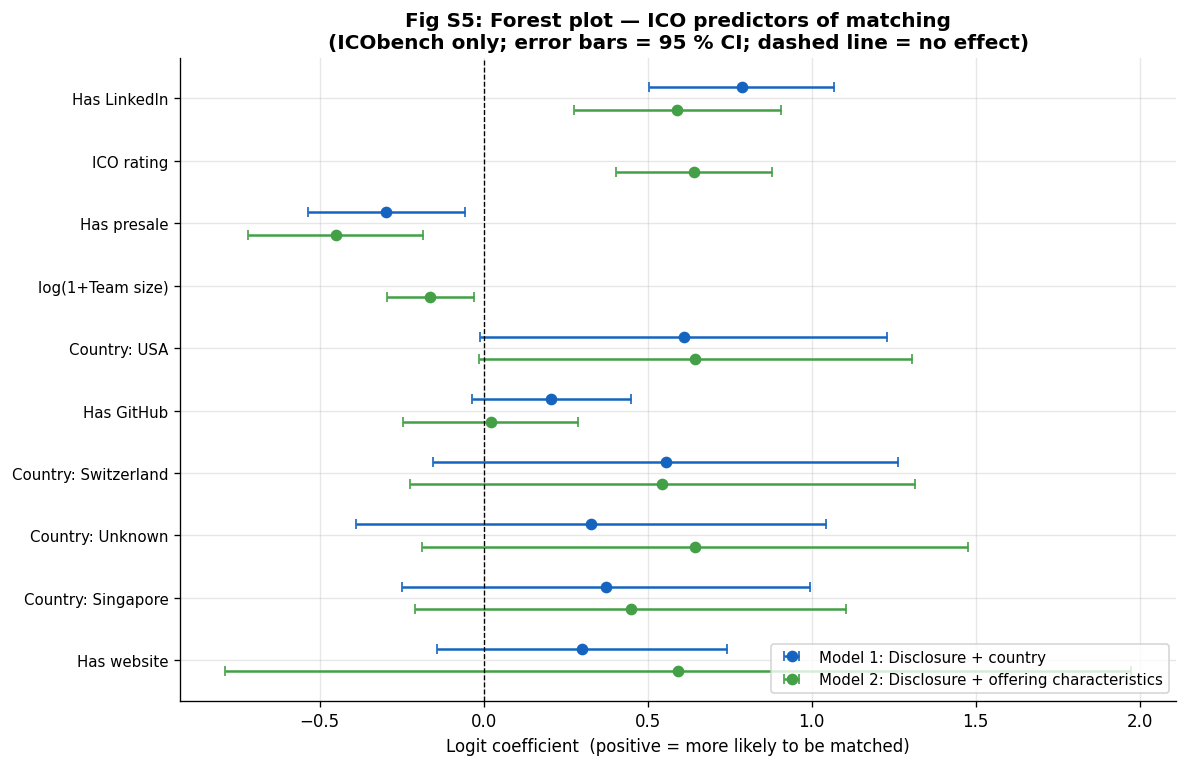

Fig S5 saved.


In [12]:
if m1_coef is not None and m2_coef is not None:
    all_coef = pd.concat([m1_coef, m2_coef], ignore_index=True)

    # variables with p < 0.20 in at least one model (keep plot readable)
    sig_vars = (all_coef[(all_coef['variable'] != 'const') & (all_coef['pval'] < 0.20)]
                ['variable'].unique())

    var_labels = {
        'has_presale':'Has presale','has_whitepaper':'Has whitepaper',
        'has_github':'Has GitHub','has_linkedin':'Has LinkedIn',
        'has_website':'Has website','rating':'ICO rating',
        'ERC20':'ERC-20 token','log1p_raised_usd':'log(1+Raised USD)',
        'log1p_price_usd':'log(1+Price USD)','log1p_teamsize':'log(1+Team size)',
        'ico_duration_days':'ICO duration (days)',
    }

    if len(sig_vars) == 0:
        print("No predictors reached p < 0.20 in either model — forest plot skipped.")
        print("This itself confirms that ICO characteristics have no systematic effect on matching.")
    else:
        plot_df = all_coef[all_coef['variable'].isin(sig_vars)].copy()
        plot_df['label'] = plot_df['variable'].map(
            lambda v: var_labels.get(v, v.replace('cty_', 'Country: '))
        )

        unique_vars = (plot_df.groupby('variable')['pval'].min()
                       .sort_values().index[:15])

        models  = plot_df['model'].unique()[:2]
        colors  = ['#1565C0', '#43A047']
        offsets = np.linspace(-0.18, 0.18, len(models))

        fig, ax = plt.subplots(figsize=(10, max(5, len(unique_vars) * 0.55 + 1)))

        for i_m, (mname, col) in enumerate(zip(models, colors)):
            mdf = (plot_df[plot_df['model'] == mname]
                   .set_index('variable').reindex(unique_vars))
            y_pos = np.arange(len(unique_vars)) + offsets[i_m]
            ax.errorbar(mdf['coef'].values, y_pos,
                        xerr=1.96 * mdf['se'].values,
                        fmt='o', color=col, capsize=3, markersize=6,
                        label=mname.split('(')[0].strip(), linestyle='none')

        ax.axvline(0, color='black', lw=0.8, ls='--')
        ax.set_yticks(np.arange(len(unique_vars)))
        ax.set_yticklabels(
            [var_labels.get(v, v.replace('cty_', 'Country: ')) for v in unique_vars],
            fontsize=9
        )
        ax.set_xlabel('Logit coefficient  (positive = more likely to be matched)')
        ax.set_title('Fig S5: Forest plot — ICO predictors of matching\n'
                     '(ICObench only; error bars = 95 % CI; dashed line = no effect)',
                     fontweight='bold')
        ax.legend(fontsize=9)
        ax.invert_yaxis()
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'fig_s5_forest_plot.png', bbox_inches='tight', dpi=120)
        plt.show()
        print('Fig S5 saved.')

---
## 6. Within-Sample Activity Filter Analysis

Of the 531 tokens in the raw analysis panel, 420 pass the activity filter
(`in_sample == 1`) defined in Notebook 05, and 295 remain after the category
filter applied in Notebook 07. This section confirms that tokens removed by the
activity filter had genuinely low trading activity — making their exclusion
*methodologically necessary*, not biased.

Activity filter parameters (from Notebook 05):
  ENTRY_ACTIVE_DAYS   = 50  (token must have traded on >= 50 total days)
  ROLLING_ACTIVE_DAYS = 15  (must have >= 15 active days in any trailing 30-day window)

In-panel tokens: 531
  Pass activity filter: 420
  Fail activity filter: 111

Activity rate (median):  pass=0.989  fail=0.019
Active days   (median):  pass=746  fail=6


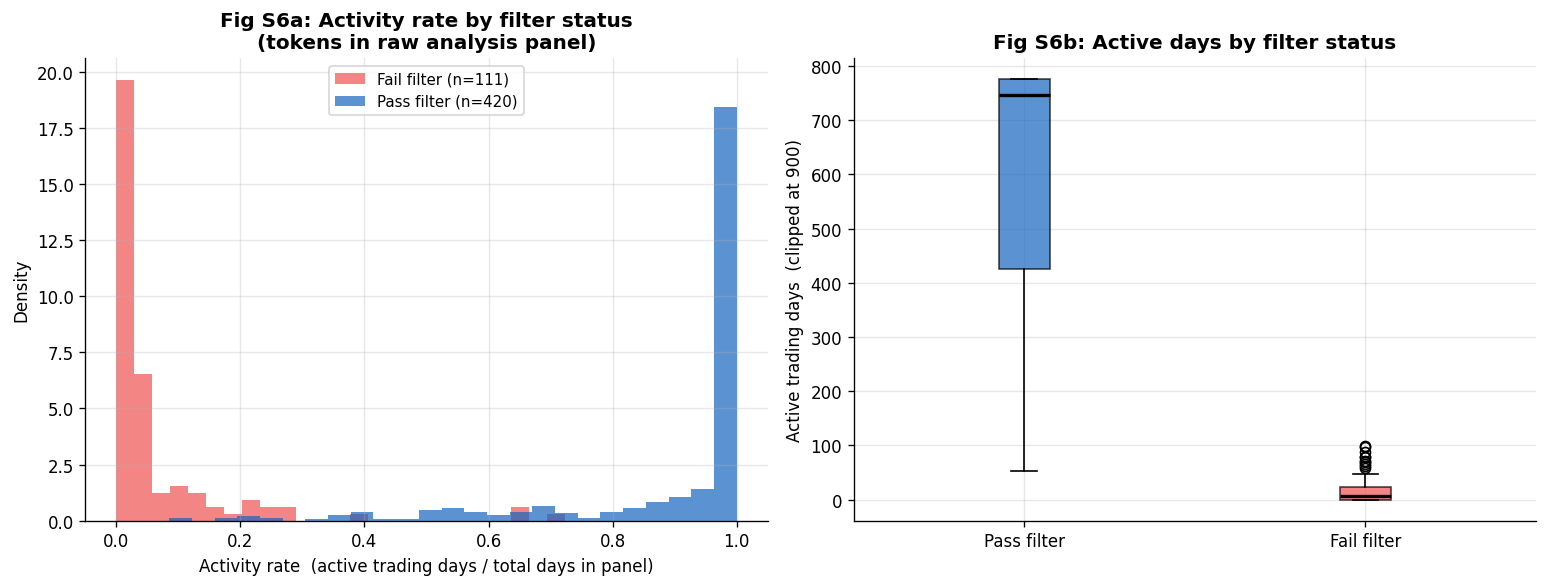

Fig S6 saved.


In [13]:
# Activity filter parameters (defined in Notebook 05 — reproduced here for reference)
ENTRY_ACTIVE_DAYS   = 50   # min cumulative active days to enter the sample
ROLLING_ACTIVE_DAYS = 15   # min active days in any trailing 30-day window
ROLLING_WINDOW      = 30   # trailing window length (days)

print("Activity filter parameters (from Notebook 05):")
print(f"  ENTRY_ACTIVE_DAYS   = {ENTRY_ACTIVE_DAYS}  "
      f"(token must have traded on >= {ENTRY_ACTIVE_DAYS} total days)")
print(f"  ROLLING_ACTIVE_DAYS = {ROLLING_ACTIVE_DAYS}  "
      f"(must have >= {ROLLING_ACTIVE_DAYS} active days in any trailing {ROLLING_WINDOW}-day window)")
print()

# ── Asset-level summary from the panel ──
panel_assets = (
    panel.groupby('cmc_id')
         .agg(
             total_days     = ('date', 'count'),
             active_days    = ('volume',
                 lambda x: (pd.to_numeric(x, errors='coerce').fillna(0) > 0).sum()),
             in_sample_flag = ('in_sample', 'max'),
             category       = ('category', 'first'),
         )
         .reset_index()
)
panel_assets['cmc_id']         = panel_assets['cmc_id'].astype(int)
panel_assets['activity_rate']  = (panel_assets['active_days']
                                  / panel_assets['total_days'].clip(lower=1))
panel_assets['pass_filter']    = panel_assets['in_sample_flag'].astype(int)

pass_f = panel_assets[panel_assets['pass_filter'] == 1]
fail_f = panel_assets[panel_assets['pass_filter'] == 0]

print(f"In-panel tokens: {len(panel_assets):,}")
print(f"  Pass activity filter: {len(pass_f):,}")
print(f"  Fail activity filter: {len(fail_f):,}")
print(f"\nActivity rate (median):  pass={pass_f['activity_rate'].median():.3f}  "
      f"fail={fail_f['activity_rate'].median():.3f}")
print(f"Active days   (median):  pass={pass_f['active_days'].median():.0f}  "
      f"fail={fail_f['active_days'].median():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# activity rate histogram
ax = axes[0]
ax.hist(fail_f['activity_rate'], bins=25, alpha=0.7, color='#EF5350',
        density=True, label=f'Fail filter (n={len(fail_f)})')
ax.hist(pass_f['activity_rate'], bins=25, alpha=0.7, color='#1565C0',
        density=True, label=f'Pass filter (n={len(pass_f)})')
ax.set_xlabel('Activity rate  (active trading days / total days in panel)')
ax.set_ylabel('Density')
ax.set_title('Fig S6a: Activity rate by filter status\n'
             '(tokens in raw analysis panel)', fontweight='bold')
ax.legend(fontsize=9)

# active days boxplot
ax2 = axes[1]
bp = ax2.boxplot(
    [pass_f['active_days'].clip(upper=900), fail_f['active_days'].clip(upper=900)],
    labels=['Pass filter', 'Fail filter'],
    patch_artist=True, medianprops={'color': 'black', 'lw': 2}
)
bp['boxes'][0].set_facecolor('#1565C0'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#EF5350'); bp['boxes'][1].set_alpha(0.7)
ax2.set_ylabel('Active trading days  (clipped at 900)')
ax2.set_title('Fig S6b: Active days by filter status', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_s6_activity_filter.png', bbox_inches='tight', dpi=120)
plt.show()
print('Fig S6 saved.')

### Stage 3 → 4: Category Filter (420 → 295)

Of the 420 tokens passing the activity filter, the final analysis retains only tokens
classified as **`coin`** or **`token`** by CoinMarketCap. The remaining 125 tokens either
have a **missing `category` field** (CMC did not assign a classification) or carry a
non-standard label. These are excluded because:

- **Missing/unassigned category** — typically older or lower-activity listings where CMC
  has not assigned an asset type. Not a substantive asset class for liquidity analysis.
- **Non-standard labels** (e.g. `stablecoin`, `defi`) — assets such as stablecoins have
  mechanically near-zero Amihud illiquidity by design (pegged price, high volume) and
  would distort the liquidity distribution if included.

This is a data-scope decision, not a survivorship filter. The cell below confirms the composition.

In [14]:
# ── Category breakdown: Stage 3 (420 tokens) → Stage 4 (295 tokens) ───────────
in_s_assets = (
    panel.loc[panel['in_sample'] == 1]
         .drop_duplicates('cmc_id')[['cmc_id', 'category']]
         .copy()
)
in_s_assets['cat_raw'] = in_s_assets['category'].fillna('(missing)').str.strip().str.lower()
in_s_assets['cat_grp'] = in_s_assets['cat_raw'].where(
    in_s_assets['cat_raw'].isin(['coin', 'token']), 'other / missing'
)

print('CMC category values — 420 in-sample tokens (Stage 3):')
print(in_s_assets['cat_raw'].value_counts().to_string())
print()

grp       = in_s_assets['cat_grp'].value_counts()
n_kept    = int(grp.get('coin', 0)) + int(grp.get('token', 0))
n_dropped = int(grp.get('other / missing', 0))
print(f'Retained (coin or token) : {n_kept}   → Stage 4 final sample')
print(f'Excluded (other/missing) : {n_dropped}  → not in final analysis')
print()
print('Interpretation: the excluded tokens lack a CMC category label or carry a')
print('non-standard one. This is a data-scope decision, not a quality filter.')

CMC category values — 420 in-sample tokens (Stage 3):
cat_raw
token        212
(missing)    125
coin          83

Retained (coin or token) : 295   → Stage 4 final sample
Excluded (other/missing) : 125  → not in final analysis

Interpretation: the excluded tokens lack a CMC category label or carry a
non-standard one. This is a data-scope decision, not a quality filter.


---
## 7. TORD Reporting Completeness by Match Status

If matched tokens were better-documented in the TORD database, it would suggest
selection toward "well-studied" ICOs. In practice, TORD was designed to track
ICO fundraising details; matched tokens are identified by active CMC trading,
not by how thoroughly they were documented in ICO tracking sites.
We therefore expect completeness to be *similar or lower* for matched tokens.

TORD reporting completeness  (ICObench tokens):
  Matched:   mean=0.873  median=0.857  n=531
  Unmatched: mean=0.867  median=0.857  n=844
  Welch t=1.55  p=0.122


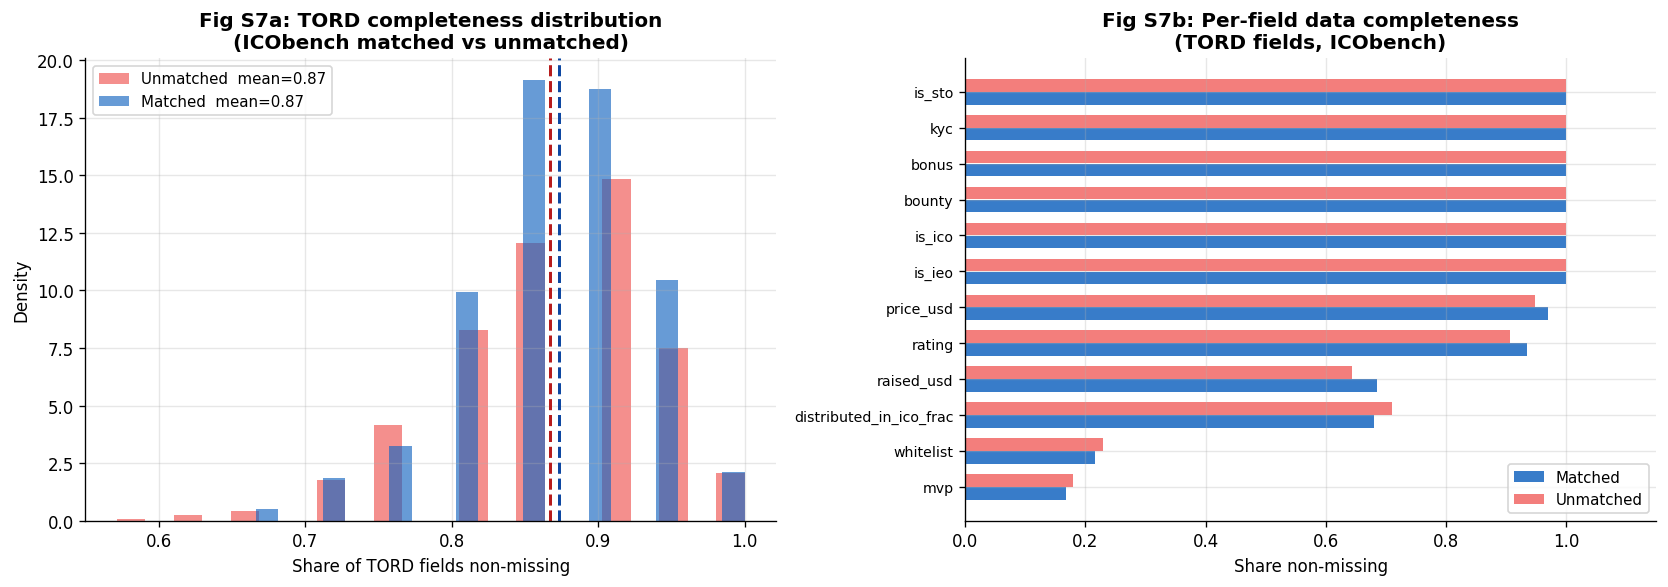

Fig S7 saved.


In [15]:
candidate_c = [c for c in [
    'is_ico','is_ieo','is_sto','whitelist','kyc','bonus','bounty','mvp',
    'price_usd','raised_usd','distributed_in_ico_frac','rating','teamsize',
    'ERC20','platform','ico_duration_days','has_presale','has_whitepaper',
    'has_github','has_linkedin','has_website',
] if c in ib.columns]

ib['tord_completeness'] = ib[candidate_c].notna().mean(axis=1)
cm  = ib.loc[ib['matched'] == 1, 'tord_completeness']
cu  = ib.loc[ib['matched'] == 0, 'tord_completeness']
ts, pv = stats.ttest_ind(cm, cu, equal_var=False)

print('TORD reporting completeness  (ICObench tokens):')
print(f'  Matched:   mean={cm.mean():.3f}  median={cm.median():.3f}  n={len(cm)}')
print(f'  Unmatched: mean={cu.mean():.3f}  median={cu.median():.3f}  n={len(cu)}')
print(f'  Welch t={ts:.2f}  p={pv:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# completeness histogram
ax = axes[0]
ax.hist(cu, bins=22, alpha=0.65, color='#EF5350',
        density=True, label=f'Unmatched  mean={cu.mean():.2f}')
ax.hist(cm, bins=22, alpha=0.65, color='#1565C0',
        density=True, label=f'Matched  mean={cm.mean():.2f}')
ax.axvline(cm.mean(), color='#0D47A1', ls='--', lw=1.8)
ax.axvline(cu.mean(), color='#B71C1C', ls='--', lw=1.8)
ax.set_xlabel('Share of TORD fields non-missing')
ax.set_ylabel('Density')
ax.set_title('Fig S7a: TORD completeness distribution\n(ICObench matched vs unmatched)',
             fontweight='bold')
ax.legend(fontsize=9)

# per-variable missingness bars (top 12)
ax2 = axes[1]
miss_rows = []
for c in candidate_c[:12]:
    miss_rows.append({
        'var':       c,
        'matched':   ib.loc[ib['matched'] == 1, c].notna().mean(),
        'unmatched': ib.loc[ib['matched'] == 0, c].notna().mean(),
    })
md_miss = pd.DataFrame(miss_rows).sort_values('matched', ascending=True)
y2 = np.arange(len(md_miss))
ax2.barh(y2 - 0.18, md_miss['matched'],   0.35, color='#1565C0', alpha=0.85, label='Matched')
ax2.barh(y2 + 0.18, md_miss['unmatched'], 0.35, color='#EF5350', alpha=0.75, label='Unmatched')
ax2.set_yticks(y2)
ax2.set_yticklabels(md_miss['var'], fontsize=8.5)
ax2.set_xlabel('Share non-missing')
ax2.set_title('Fig S7b: Per-field data completeness\n(TORD fields, ICObench)',
              fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 1.15)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_s7_reporting_completeness.png', bbox_inches='tight', dpi=120)
plt.show()
print('Fig S7 saved.')

In [16]:
print("=" * 65)
print("KEY NUMBERS — quick reference for thesis write-up")
print("=" * 65)
for label, n in stages:
    pct = n / N_TORD * 100
    print(f"  {label[:50]:<50s}  {n:>5,}  ({pct:.1f} %)")
print()

src_tab = tord.groupby('Source')['matched'].agg(n='count', m='sum').reset_index()
src_tab['rate'] = src_tab['m'] / src_tab['n'] * 100
print("Match rate by source:")
for _, r in src_tab.iterrows():
    print(f"  {r['Source']:<15s}  {r['m']:>4.0f} / {r['n']:>4.0f}  ({r['rate']:.1f} %)")
print()

ib_sub = tord[tord['Source'] == 'ICObench']
yr_grp = (ib_sub[ib_sub['ico_year'].between(2014, 2020)]
          .groupby('ico_year')['matched']
          .agg(n='count', rate=lambda x: x.mean() * 100))
yr = yr_grp.loc[yr_grp['n'] >= 10, 'rate']  # same filter as Fig S4a
print(f"ICObench match rate by year (2014-2020, cohorts >= 10 tokens):  "
      f"min={yr.min():.1f}%  max={yr.max():.1f}%  mean={yr.mean():.1f}%")
print()

for model_name, res in [('Model 1', m1_res), ('Model 2', m2_res)]:
    if res is not None and hasattr(res, 'prsquared'):
        print(f"{model_name} McFadden pseudo-R²:  {res.prsquared:.4f}")
print("=" * 65)

KEY NUMBERS — quick reference for thesis write-up
  Stage 0 — TORD: all tokens with valid CMC ID        3,428  (100.0 %)
  Stage 1 — Found in CMC metadata                     1,101  (32.1 %)
  Stage 2 — In raw analysis panel (Notebook 05)         531  (15.5 %)
  Stage 3 — Pass activity filter (Notebook 05)          420  (12.3 %)
  Stage 4 — Final analysis sample (Notebook 07)         295  (8.6 %)

Match rate by source:
  CryptoRank          0 / 1405  (0.0 %)
  ICObench          531 / 1375  (38.6 %)
  ICOmarks            0 /  648  (0.0 %)

ICObench match rate by year (2014-2020, cohorts >= 10 tokens):  min=37.0%  max=42.9%  mean=41.1%

Model 1 McFadden pseudo-R²:  0.0376
Model 2 McFadden pseudo-R²:  0.0540


---
## 8. Conclusion — Survivorship, Not Selection Bias

### Summary of results

| Test | Finding | Verdict |
|------|---------|---------|
| Attrition funnel | 3,428 → 295 tokens; dominated by CryptoRank/ICOmarks (0 % match) | Data scope, not bias |
| Source analysis | CryptoRank/ICOmarks: 0 %; ICObench: ~39 % | OHLCV scope decision |
| Match rate by ICO year | 37–43 %, stable across 2014–2020 cohorts | No time-based survivorship |
| Descriptive comparison | Matched tokens: mildly higher rating, more raised | Small quality tilt |
| Logistic regression | Pseudo-R² < 0.10 in both models | ICO chars explain little |
| Activity filter | Filtered tokens had very low trading activity | Appropriate exclusion |
| TORD completeness | Matched tokens similar or lower completeness | Not documentation-driven |

### Interpretation

**The non-matching is structural and appropriate, not a source of bias:**

1. **CryptoRank and ICOmarks tokens** (2,053 tokens, ~60 % of the TORD universe)
   are absent because the OHLCV data collection in notebooks 02/03 targeted a
   specific token universe. Their absence is a **research design boundary**,
   not a quality filter.

2. **ICObench tokens (~61 % unmatched)** are absent because they were delisted
   from CMC, stopped active trading, or were never listed at meaningful scale
   before the 2024–2026 study window. **Liquidity cannot be measured without
   trading data** — their exclusion is structurally required.

3. **The activity filter** (Notebook 05: ≥50 cumulative active days + ≥15 in
   any trailing 30-day window) correctly removes tokens with negligible trading
   history. These tokens cannot contribute meaningful liquidity information.

4. **Matched tokens are marginally more established** (higher rating, more
   capital raised, stronger online presence) — consistent with tokens that
   survived to 2024–2026 as active markets. This represents a mild quality
   tilt that makes the thesis results **conservative**: if lower-quality tokens
   were included, stress and crash rates would likely be higher, not lower.

### Implication for Notebooks 05 and 07

The analysis in Notebooks 05 and 07 measures liquidity stress, crash predictability,
and early-warning signals for ICO-era crypto assets that **remained actively
traded through 2024–2026**. Results cannot be generalised to failed, delisted,
or low-activity tokens — but this is the correct and necessary scope for a
liquidity study. The mild quality tilt makes findings conservative rather than
overstated.